In [19]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 1. 데이터 불러오기

In [20]:
df = pd.read_csv("dataset/sleep_health_dataset.csv")

print(df.shape)
df.head()

(100000, 32)


,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   gender                       100000 non-null  object 
 3   occupation                   100000 non-null  object 
 4   bmi                          100000 non-null  float64
 5   country                      100000 non-null  object 
 6   sleep_duration_hrs           100000 non-null  float64
 7   sleep_quality_score          100000 non-null  float64
 8   rem_percentage               100000 non-null  float64
 9   deep_sleep_percentage        100000 non-null  float64
 10  sleep_latency_mins           100000 non-null  int64  
 11  wake_episodes_per_night      100000 non-null  int64  
 12  caffeine_mg_before_bed       100000 non-null  int64  
 13  

## 2. 불필요한 컬럼 제거

In [22]:
drop_cols = [
    "person_id",
    "weekend_sleep_diff_hrs",
    "nap_duration_mins",
    "room_temperature_celsius",
    "age",
    "steps_that_day",
    "exercise_day",
    "cognitive_performance_score"
]

df = df.drop(columns=drop_cols)

print(df.shape)
df.head()

(100000, 24)


,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,...,work_hours_that_day,chronotype,mental_health_condition,heart_rate_resting_bpm,sleep_aid_used,shift_work,season,day_type,sleep_disorder_risk,felt_rested
0,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,16,3,...,10.7,Morning,Healthy,63,0,0,Autumn,Weekday,Healthy,0
1,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,17,4,...,3.0,Neutral,Healthy,52,1,0,Winter,Weekend,Healthy,1
2,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,26,4,...,3.6,Neutral,Both,72,0,1,Spring,Weekend,Severe,0
3,Female,Student,29.5,India,6.79,6.4,17.7,17.7,13,4,...,6.7,Morning,Healthy,71,0,0,Summer,Weekend,Healthy,0
4,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,30,5,...,10.4,Neutral,Healthy,71,0,0,Summer,Weekday,Mild,0


## 3. 결측치 확인

In [23]:
df.isnull().sum().sort_values(ascending=False)

gender                         0
occupation                     0
bmi                            0
country                        0
sleep_duration_hrs             0
sleep_quality_score            0
rem_percentage                 0
deep_sleep_percentage          0
sleep_latency_mins             0
wake_episodes_per_night        0
caffeine_mg_before_bed         0
alcohol_units_before_bed       0
screen_time_before_bed_mins    0
stress_score                   0
work_hours_that_day            0
chronotype                     0
mental_health_condition        0
heart_rate_resting_bpm         0
sleep_aid_used                 0
shift_work                     0
season                         0
day_type                       0
sleep_disorder_risk            0
felt_rested                    0
dtype: int64

## 4. EDA (탐색적 데이터 분석)

### 수면의 질 점수 분포

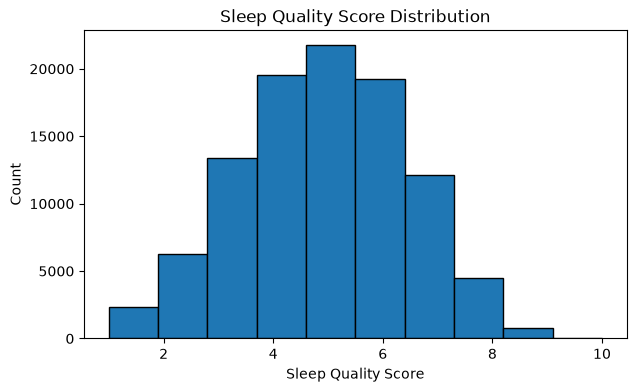

In [24]:
plt.figure(figsize=(7, 4))
plt.hist(df["sleep_quality_score"], bins=10, edgecolor="black")
plt.title("Sleep Quality Score Distribution")
plt.xlabel("Sleep Quality Score")
plt.ylabel("Count")
plt.show()

### 주요 수치형 변수 분포

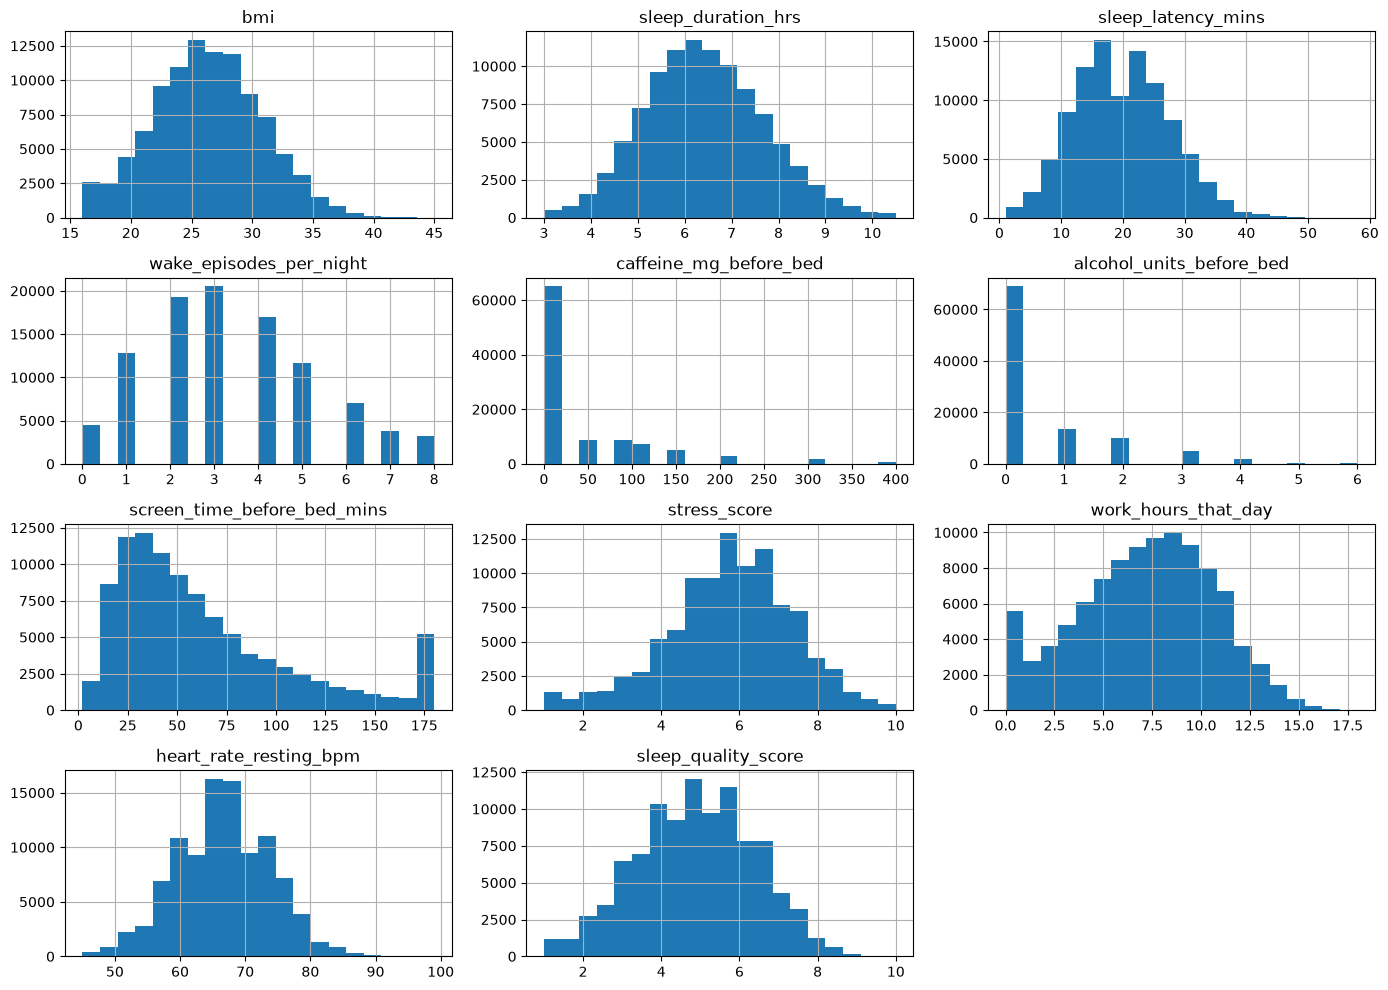

In [25]:
eda_cols = [
    "bmi",
    "sleep_duration_hrs",
    "sleep_latency_mins",
    "wake_episodes_per_night",
    "caffeine_mg_before_bed",
    "alcohol_units_before_bed",
    "screen_time_before_bed_mins",
    "stress_score",
    "work_hours_that_day",
    "heart_rate_resting_bpm",
    "sleep_quality_score"
]

df[eda_cols].hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.show()

### 수면 시간과 수면의 질 관계

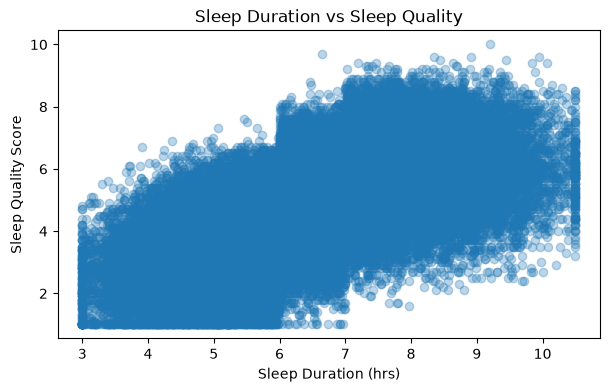

In [26]:
plt.figure(figsize=(7, 4))
plt.scatter(
    df["sleep_duration_hrs"],
    df["sleep_quality_score"],
    alpha=0.3
)
plt.title("Sleep Duration vs Sleep Quality")
plt.xlabel("Sleep Duration (hrs)")
plt.ylabel("Sleep Quality Score")
plt.show()

### 스트레스와 수면의 질 관계

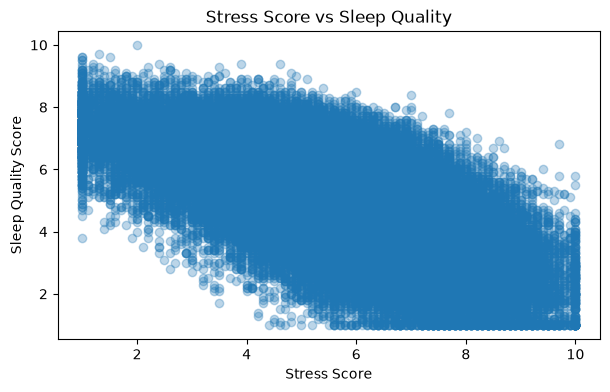

In [27]:
plt.figure(figsize=(7, 4))
plt.scatter(
    df["stress_score"],
    df["sleep_quality_score"],
    alpha=0.3
)
plt.title("Stress Score vs Sleep Quality")
plt.xlabel("Stress Score")
plt.ylabel("Sleep Quality Score")
plt.show()

### 수치형 변수 상관관계

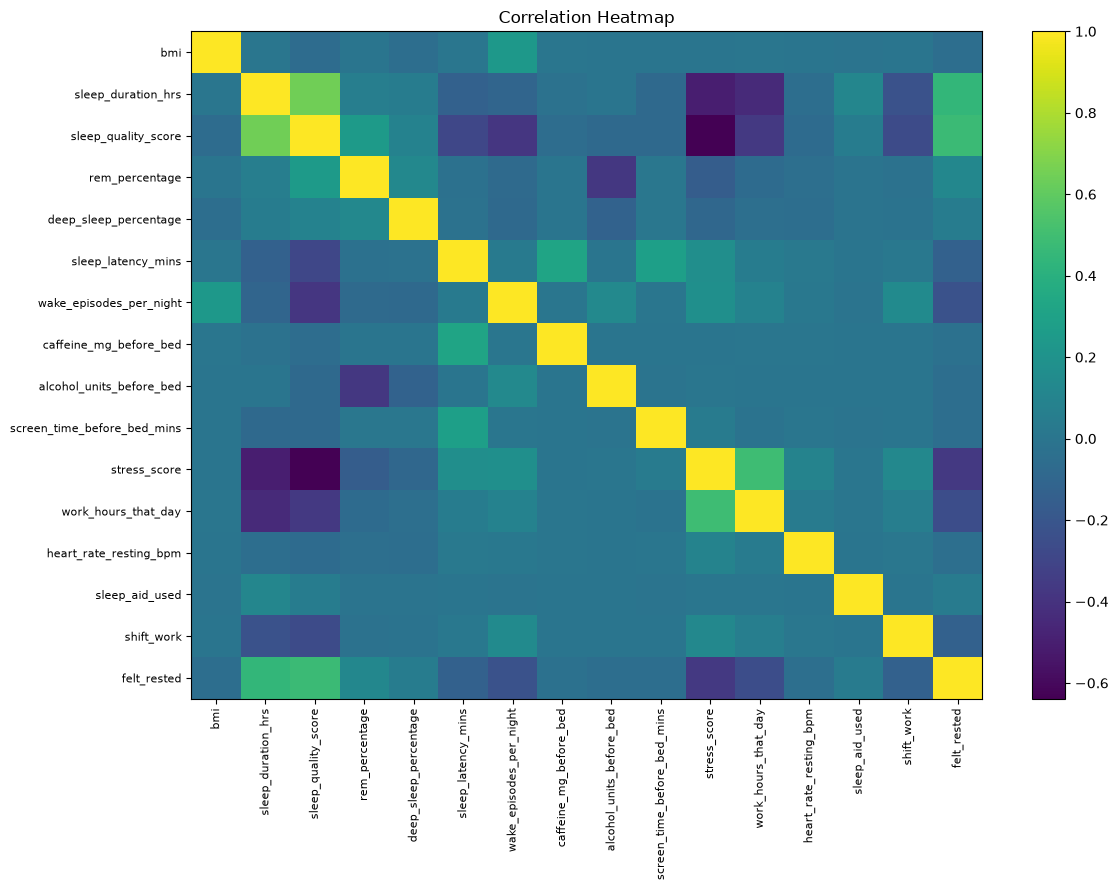

In [28]:
corr = df.select_dtypes(include=["number", "bool"]).corr()

plt.figure(figsize=(12, 9))
plt.imshow(corr, aspect="auto")
plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90,
    fontsize=8
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns,
    fontsize=8
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## 5. 최종 입력 데이터 구성

In [29]:
X = df.drop(columns=[
    "sleep_quality_score",
    "sleep_disorder_risk",
    "rem_percentage",
    "deep_sleep_percentage",
    "felt_rested",
    "gender",
    "occupation",
    "country",
    "season",
    "day_type"
])

y = df["sleep_quality_score"]

print("입력 변수 개수:", X.shape[1])
print(X.columns.tolist())

입력 변수 개수: 14
['bmi', 'sleep_duration_hrs', 'sleep_latency_mins', 'wake_episodes_per_night', 'caffeine_mg_before_bed', 'alcohol_units_before_bed', 'screen_time_before_bed_mins', 'stress_score', 'work_hours_that_day', 'chronotype', 'mental_health_condition', 'heart_rate_resting_bpm', 'sleep_aid_used', 'shift_work']


In [30]:
categorical_cols = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_cols = X.select_dtypes(
    include=["number", "bool"]
).columns.tolist()

print("문자형 컬럼:", categorical_cols)
print("숫자형 컬럼:", numerical_cols)

문자형 컬럼: ['chronotype', 'mental_health_condition']
숫자형 컬럼: ['bmi', 'sleep_duration_hrs', 'sleep_latency_mins', 'wake_episodes_per_night', 'caffeine_mg_before_bed', 'alcohol_units_before_bed', 'screen_time_before_bed_mins', 'stress_score', 'work_hours_that_day', 'heart_rate_resting_bpm', 'sleep_aid_used', 'shift_work']


## 6. 전처리 및 학습/테스트 데이터 분리

In [31]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (80000, 14)
X_test: (20000, 14)


## 7. 여러 회귀 모델 성능 비교

In [32]:
models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),
    "Extra Trees": ExtraTreesRegressor(
        n_estimators=100,
        random_state=42
    ),
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    )
}

results = []

for name, regressor in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", regressor)
    ])

    pipeline.fit(X_train, y_train)
    pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

result_df = pd.DataFrame(results).sort_values("R2", ascending=False)
result_df

,Model,MAE,RMSE,R2
0,Random Forest,0.537894,0.673824,0.802210
1,Extra Trees,0.544214,0.681759,0.797524
2,Linear Regression,0.600264,0.750762,0.754464
3,Decision Tree,0.764860,0.959418,0.599017


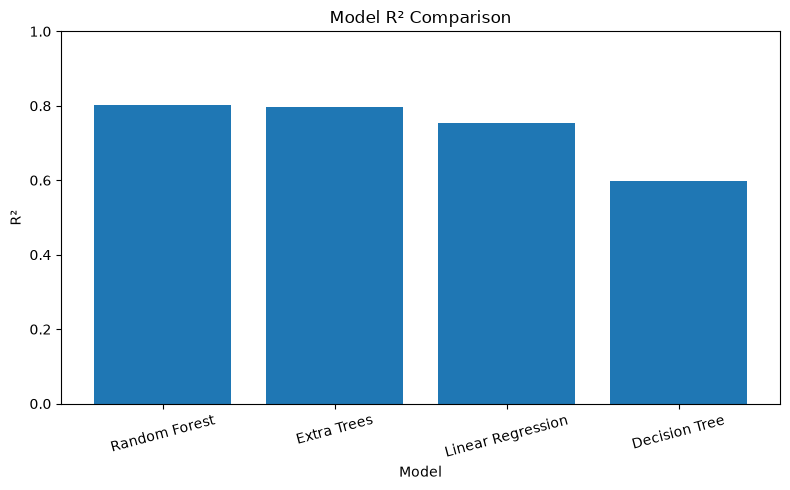

In [38]:
# 모델 성능 비교 그래프

plt.figure(figsize=(8, 5))
plt.bar(result_df["Model"], result_df["R2"])

plt.title("Model R² Comparison")
plt.xlabel("Model")
plt.ylabel("R²")
plt.ylim(0, 1)

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 8. 최종 Random Forest 모델 학습

In [33]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

model.fit(X_train, y_train)

print("학습 완료!")
print(model.feature_names_in_.tolist())

학습 완료!
['bmi', 'sleep_duration_hrs', 'sleep_latency_mins', 'wake_episodes_per_night', 'caffeine_mg_before_bed', 'alcohol_units_before_bed', 'screen_time_before_bed_mins', 'stress_score', 'work_hours_that_day', 'chronotype', 'mental_health_condition', 'heart_rate_resting_bpm', 'sleep_aid_used', 'shift_work']


## 9. 최종 모델 성능 평가

In [34]:
pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print(f"MAE  : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"R²   : {r2:.6f}")

MAE  : 0.537894
RMSE : 0.673824
R²   : 0.802210


## 10. 실제값과 예측값 확인

In [35]:
comparison = pd.DataFrame({
    "Actual": y_test.reset_index(drop=True),
    "Predicted": pred
})

comparison.head(10)

,Actual,Predicted
0,3.6,3.656
1,1.2,2.155
2,5.6,5.296
3,2.7,1.950
4,3.8,4.298
5,4.9,5.327
6,5.8,5.558
7,2.5,3.057
8,6.6,6.375
9,4.5,4.381


## 11. 모델 저장

In [36]:
joblib.dump(model, "sleep_model.pkl")
print("sleep_model.pkl 저장 완료")

sleep_model.pkl 저장 완료


## 12. 저장한 모델 확인

In [37]:
check_model = joblib.load("sleep_model.pkl")

print(check_model.feature_names_in_.tolist())

['bmi', 'sleep_duration_hrs', 'sleep_latency_mins', 'wake_episodes_per_night', 'caffeine_mg_before_bed', 'alcohol_units_before_bed', 'screen_time_before_bed_mins', 'stress_score', 'work_hours_that_day', 'chronotype', 'mental_health_condition', 'heart_rate_resting_bpm', 'sleep_aid_used', 'shift_work']
